# ElasticNet (L1 + L2)

**Flow:** correlated feature groups → mix L1/L2 → tune with ElasticNetCV on training data → held-out evaluation.

ElasticNet blends Lasso feature selection with Ridge-like stability. We keep `l1_ratio` strictly greater than 0 so the model is a genuine ElasticNet (l1_ratio=0 would be pure Ridge and is avoided here).

## 1. Setup and versions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]


In [2]:
# Environment / version info for reproducibility
import sys
import numpy as np
import scipy
import sklearn
import matplotlib

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. Correlated feature group + noise, split before fitting
Features x1 and x2 both track a latent z (correlated group); x3 and x4 are noise.

In [3]:
z = rng.normal(size=180)
X = np.c_[
    z + 0.1 * rng.normal(size=180),
    z + 0.1 * rng.normal(size=180),
    rng.normal(size=180),
    rng.normal(size=180),
]
y = 2 * z + rng.normal(0, 1, size=180)
feature_names = ['x1 (~z)', 'x2 (~z)', 'x3 (noise)', 'x4 (noise)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)
print(f'Train/test sizes: {X_train.shape[0]} / {X_test.shape[0]}')


Train/test sizes: 126 / 54


## 3. Effect of l1_ratio on coefficients (l1_ratio > 0)
We sweep l1_ratio over values strictly greater than 0. Larger l1_ratio means more Lasso-like sparsity. Each feature uses a distinct color and marker.

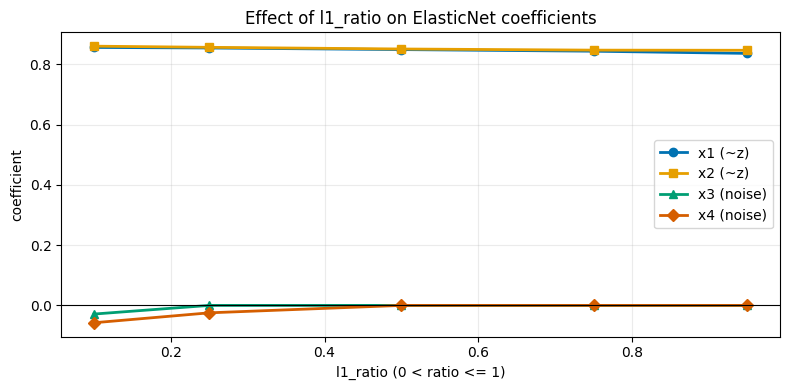

In [4]:
ratios = [0.1, 0.25, 0.5, 0.75, 0.95]  # strictly > 0: genuine ElasticNet
coefs = []
for r in ratios:
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('enet', ElasticNet(alpha=0.25, l1_ratio=r, max_iter=10000)),
    ]).fit(X_train, y_train)
    coefs.append(pipe.named_steps['enet'].coef_)
coefs = np.array(coefs)

markers = ['o', 's', '^', 'D']
plt.figure(figsize=(8, 4))
for j, name in enumerate(feature_names):
    plt.plot(ratios, coefs[:, j], color=OKABE_ITO[j], marker=markers[j],
             lw=2, label=name)
plt.axhline(0, color='black', lw=0.8)
plt.title('Effect of l1_ratio on ElasticNet coefficients')
plt.xlabel('l1_ratio (0 < ratio <= 1)'); plt.ylabel('coefficient')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 4. Tune alpha and l1_ratio with ElasticNetCV on training data
`ElasticNetCV` cross-validates both the penalty strength and the L1/L2 mix using only training data. The l1_ratio grid excludes 0.

In [5]:
enet_cv = Pipeline([
    ('scale', StandardScaler()),
    ('enet', ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                          n_alphas=50, cv=5, max_iter=20000,
                          random_state=0)),
]).fit(X_train, y_train)

enet = enet_cv.named_steps['enet']
print(f'Best alpha    : {enet.alpha_:.4g}')
print(f'Best l1_ratio : {enet.l1_ratio_:.3g}')
print(f'Coefficients  : {np.round(enet.coef_, 3)}')


Best alpha    : 0.05153
Best l1_ratio : 0.1
Coefficients  : [ 0.932  0.957 -0.044 -0.104]


## 5. Compare Ridge, Lasso, ElasticNetCV on held-out data
All three models are fit on training data (with tuning where applicable) and evaluated once on the test set. Grouped bars use distinct colors; the metrics table prints exact values.

model            test R2    test MSE
------------------------------------
Ridge              0.470       1.119
Lasso              0.543       0.965
ElasticNetCV       0.485       1.086


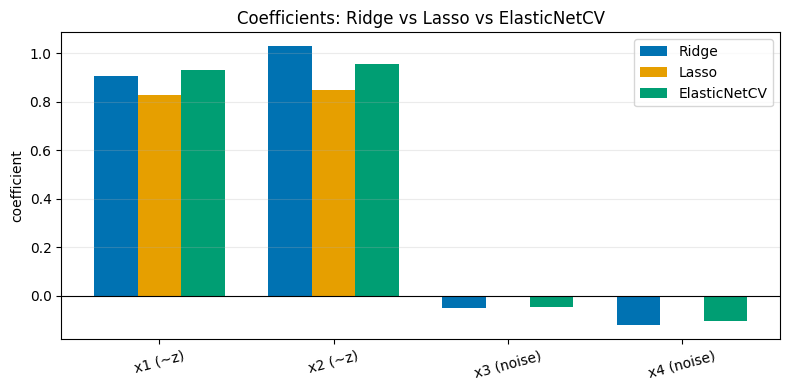

In [6]:
fitted = {
    'Ridge': Pipeline([('scale', StandardScaler()),
                       ('m', Ridge(alpha=0.25))]).fit(X_train, y_train),
    'Lasso': Pipeline([('scale', StandardScaler()),
                       ('m', Lasso(alpha=0.25, max_iter=10000))]).fit(X_train, y_train),
    'ElasticNetCV': enet_cv,
}

def coef_of(model):
    step = 'enet' if 'enet' in model.named_steps else 'm'
    return model.named_steps[step].coef_

print(f'{"model":<14}{"test R2":>10}{"test MSE":>12}')
print('-' * 36)
for name, model in fitted.items():
    pred = model.predict(X_test)
    print(f'{name:<14}{r2_score(y_test, pred):>10.3f}'
          f'{mean_squared_error(y_test, pred):>12.3f}')

width = 0.25
pos = np.arange(X.shape[1])
plt.figure(figsize=(8, 4))
for i, (name, model) in enumerate(fitted.items()):
    plt.bar(pos + (i - 1) * width, coef_of(model), width,
            color=OKABE_ITO[i], label=name)
plt.axhline(0, color='black', lw=0.8)
plt.xticks(pos, feature_names, rotation=15)
plt.title('Coefficients: Ridge vs Lasso vs ElasticNetCV')
plt.ylabel('coefficient'); plt.legend()
plt.grid(alpha=0.25, axis='y'); plt.tight_layout(); plt.show()


## Takeaways
- ElasticNet needs `l1_ratio > 0`; l1_ratio=0 is pure Ridge and is avoided.
- Tune both alpha and l1_ratio with ElasticNetCV on training data.
- For correlated groups it can share weight more gracefully than pure Lasso.